In [ ]:

from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils import make_unique_save_path, save_config

is_train_data = True
mkdir = False


data_path = 'train_imges' if is_train_data else 'test_images'
data_name = 'DIV2K_train_HR' if is_train_data else 'DIV2K_valid_HR'

RAW_DIR = Path(f"./{data_path}/{data_name}")
OUT_DIR = Path(f"./{data_path}/{data_name}_processed")

POISSON_DIR = Path(f"./{data_path}/{data_name}_poisson")

if (mkdir): OUT_DIR = make_unique_save_path(OUT_DIR)

CONFIG_PATH = OUT_DIR / Path(f"data_{data_name}_config.json")

# OUT_DIR.mkdir(parents=True, exist_ok=True)

CHANNAL = 3
PATCH_SIZE = 128
STRIDE = PATCH_SIZE
MAX_PATCHES_PER_IMAGE = 1024
SEED = 0

rng = np.random.default_rng(SEED)


In [40]:
image_paths = sorted([
    p for p in RAW_DIR.glob("*")
    if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
])

len(image_paths), image_paths[:5]

(800,
 [PosixPath('train_imges/DIV2K_train_HR/0001.png'),
  PosixPath('train_imges/DIV2K_train_HR/0002.png'),
  PosixPath('train_imges/DIV2K_train_HR/0003.png'),
  PosixPath('train_imges/DIV2K_train_HR/0004.png'),
  PosixPath('train_imges/DIV2K_train_HR/0005.png')])

(1404, 2040, 3) 0.0 0.99607843


(-0.5, 2039.5, 1403.5, -0.5)

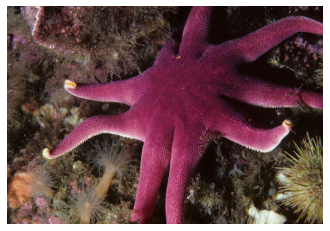

In [41]:
# 이미지 로드 함수
def load_gray_image(path):
    img = Image.open(path).convert("L")
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

def load_rgb_image(path):
    img = Image.open(path).convert("RGB")
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr  # [H, W, 3]


img = load_gray_image(image_paths[0]) if CHANNAL == 1 else load_rgb_image(image_paths[0])
print(img.shape, img.min(), img.max())

# plt.imshow(img)
plt.imshow(img, vmin=0, vmax=1) # 
plt.axis("off")

In [42]:
def convert_images_to_npy(image_paths, save_dir, channels=1):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    mode = "L" if channels == 1 else "RGB"

    npy_paths = []

    for path in tqdm(image_paths):
        path = Path(path)
        img = Image.open(path).convert(mode)
        arr = np.asarray(img, dtype=np.uint8)

        save_path = save_dir / f"{path.stem}.npy"
        np.save(save_path, arr)

        npy_paths.append(save_path)

    return npy_paths

In [43]:
def convert_images_to_poisson_npy(
    image_paths,
    save_root,
    noise_levels=(0.01, 0.05),
    channels=1,
    save_clean=False,
    seed=None,
):
    """
    이미지를 [0, 1] 범위로 정규화한 뒤 포아송 노이즈를 추가하여
    각 noise level별 .npy 파일로 저장한다.

    Parameters
    ----------
    image_paths : iterable
        입력 이미지 경로 목록.
    save_root : str or Path
        결과를 저장할 최상위 디렉터리.
    noise_levels : tuple of float
        포아송 노이즈 파라미터 eta 값들.
        값이 클수록 일반적으로 노이즈가 강하다.
    channels : int
        1이면 grayscale, 그 외에는 RGB.
    save_clean : bool
        True이면 정규화된 clean 이미지도 저장한다.
    seed : int or None
        재현 가능한 노이즈 생성을 위한 랜덤 시드.

    Returns
    -------
    dict
        clean 및 noise level별 저장 경로 목록.
    """
    save_root = Path(save_root)
    save_root.mkdir(parents=True, exist_ok=True)

    mode = "L" if channels == 1 else "RGB"
    rng = np.random.default_rng(seed)

    output_dirs = {}

    if save_clean:
        clean_dir = save_root / "clean"
        clean_dir.mkdir(parents=True, exist_ok=True)
        output_dirs["clean"] = clean_dir

    for eta in noise_levels:
        key = f"poisson_{eta:g}"
        noise_dir = save_root / key
        noise_dir.mkdir(parents=True, exist_ok=True)
        output_dirs[eta] = noise_dir

    saved_paths = {
        key: []
        for key in output_dirs
    }

    for image_path in tqdm(image_paths):
        image_path = Path(image_path)

        with Image.open(image_path) as image:
            image = image.convert(mode)

            # uint8 [0, 255] -> float32 [0, 1]
            clean = np.asarray(image, dtype=np.float32) / 255.0

        filename = f"{image_path.stem}.npy"

        if save_clean:
            clean_path = output_dirs["clean"] / filename
            np.save(clean_path, clean)
            saved_paths["clean"].append(clean_path)

        for eta in noise_levels:
            # y = eta * Poisson(x / eta)
            noisy = rng.poisson(clean / eta).astype(np.float32) * eta

            save_path = output_dirs[eta] / filename
            np.save(save_path, noisy)
            saved_paths[eta].append(save_path)

    return saved_paths

In [44]:
num_images = len(image_paths)
max_total_patches = num_images * MAX_PATCHES_PER_IMAGE

bytes_per_patch = PATCH_SIZE * PATCH_SIZE * np.dtype(np.float32).itemsize
total_bytes = max_total_patches * bytes_per_patch

print("max_total_patches:", max_total_patches)
print("estimated data memory GB:", total_bytes / 1024**3)
print("estimated peak with concatenate GB:", total_bytes * 2 / 1024**3)
img = load_gray_image(image_paths[0])
print("img type:", img.dtype)

max_total_patches: 819200
estimated data memory GB: 50.0
estimated peak with concatenate GB: 100.0
img type: float32


In [ ]:
# 하나씩 변환
npy_paths = convert_images_to_npy(
    image_paths,
    save_dir=OUT_DIR,
    channels=CHANNAL,
)

config = {
    "RAW_DIR": RAW_DIR,
    "OUT_DIR": OUT_DIR,
    "data_name": data_name,
    "PATCH_SIZE": PATCH_SIZE,
    "STRIDE": STRIDE,
    "MAX_PATCHES_PER_IMAGE": MAX_PATCHES_PER_IMAGE,
    "SEED": SEED,
    # "data.shape": data.shape
    "max_total_patches": max_total_patches,
}


save_config(CONFIG_PATH, config)

print(f"설정 파일이 성공적으로 저장되었습니다: {CONFIG_PATH}")

In [45]:
saved_paths = convert_images_to_poisson_npy(
    image_paths=image_paths,
    save_root=POISSON_DIR,
    noise_levels=(0.01, 0.05),
    channels=CHANNAL,
    save_clean=True,
    seed=SEED,
)

config = {
    "RAW_DIR": RAW_DIR,
    "OUT_DIR": POISSON_DIR,
    "data_name": data_name,
    "PATCH_SIZE": PATCH_SIZE,
    "STRIDE": STRIDE,
    "MAX_PATCHES_PER_IMAGE": MAX_PATCHES_PER_IMAGE,
    "SEED": SEED,
    # "data.shape": data.shape
    "max_total_patches": max_total_patches,
}


save_config(POISSON_DIR / Path(f"data_{data_name}_config.json"), config)

print(f"설정 파일이 성공적으로 저장되었습니다: {POISSON_DIR}")

100%|██████████| 800/800 [15:01<00:00,  1.13s/it]

설정 파일이 성공적으로 저장되었습니다: train_imges/DIV2K_train_HR_poisson


In [9]:
from data import make_ardae_dataloader

loader = make_ardae_dataloader(
    data,
    input_dim=data.shape[1],
    batch_size=128,
    normalize=None,
)

batch = next(iter(loader))
batch.shape, batch.min(), batch.max()

(torch.Size([128, 16384]), tensor(0.), tensor(1.))